In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.spatial import cKDTree
import matplotlib.animation as animation
import sys  
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import binned_statistic

In [2]:
def map_unstructured_to_structured_3d_optimized(positions, values, grid_size):
    """
    Map data from an unstructured 3D grid to a structured 3D grid using nearest neighbor interpolation.
    This version uses more efficient numpy array operations.

    Parameters:
    - positions (np.array): Array of shape (n, 3) containing the (x, y, z) positions of unstructured data.
    - values (np.array): Array of shape (n,) containing the values at the unstructured grid points.
    - grid_size (tuple): Dimensions of the structured grid (height, width, depth).

    Returns:
    - structured_grid (np.array): A 3D array representing the structured grid values.
    """
    # Define the grid to which we want to map the unstructured data
    x_min, x_max = np.min(positions[:, 0]), np.max(positions[:, 0])
    y_min, y_max = np.min(positions[:, 1]), np.max(positions[:, 1])
    z_min, z_max = np.min(positions[:, 2]), np.max(positions[:, 2])
    grid_height, grid_width, grid_depth = grid_size

    x_grid = np.linspace(x_min, x_max, grid_width)
    y_grid = np.linspace(y_min, y_max, grid_height)
    z_grid = np.linspace(z_min, z_max, grid_depth)
    
    X_grid, Y_grid, Z_grid = np.meshgrid(x_grid, y_grid, z_grid, indexing='ij')
    
    # Reshape the grid to match the shape of the output structured grid
    if len(values.shape) < 2:
        structured_grid = np.zeros((grid_height, grid_width, grid_depth))
    else:
        structured_grid = np.zeros((grid_height, grid_width, grid_depth, values.shape[-1]))

    # Create a k-d tree for fast nearest neighbor search
    tree = cKDTree(positions)

    # Create a 3D array of coordinates for the structured grid
    grid_coords = np.vstack([X_grid.ravel(), Y_grid.ravel(), Z_grid.ravel()]).T

    # Query the k-d tree for nearest neighbors
    _, idx = tree.query(grid_coords, k=1)

    # Map values to the structured grid
    if len(values.shape) < 2:
        structured_grid = values[idx].reshape(grid_height, grid_width, grid_depth)
    else:
        structured_grid = values[idx].reshape(grid_height, grid_width, grid_depth, values.shape[-1])

    return structured_grid

In [ ]:
a = np.array([0, 0])
len(a.shape)

In [3]:
sims = ["driving128-nonsol", "driving64", "driving32", "driving128-mach10"]

sim = sims[3]

i = 60
filename = f"{sim}/output/snap_{i:03d}.hdf5" # str(sys.argv[1])
with h5py.File(filename, 'r') as file:
    gas = file["PartType0"]
    coordinates = np.array(gas["Coordinates"])
    velocities = np.array(gas["Velocities"])   
    density = np.array(gas["Density"])
    pressure = np.array(gas["Pressure"])
    acc = np.array(gas["Acceleration"])

In [ ]:
gamma = 5/3
soundspeed = np.sqrt(gamma*pressure/density)
c_s = np.mean(soundspeed)
print(c_s)
rms_vel = np.sqrt(np.mean(np.sum(velocities**2, axis=1)))
rms_acc = np.sqrt(np.mean(np.sum(acc**2, axis=1)))
print(rms_vel, rms_vel/c_s, rms_vel/75.7, rms_acc)

In [ ]:
n = 300
structured_grid = map_unstructured_to_structured_3d_optimized(coordinates, np.sqrt(np.sum(acc**2, axis=1)), (n, n, n)) # 
colheight = 300
col_dens = np.sum(structured_grid[:, :, (n//2 - colheight//2):(n//2 + colheight//2)], axis=2)/colheight
fig, ax = plt.subplots()
im = ax.imshow(col_dens, cmap='viridis', origin='lower')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax) # , label=r'$ \rho [M_{\odot}/kpc^3]$ ')

ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [3]:
vals = list()

sims = ["driving128-nonsol", "driving64", "driving32", "driving128-mach10", "driving128-mach10-forceramp", "driving128-mach0.5"]

sim = sims[5]
for i in range(198):
    filename = f"{sim}/output/snap_{i:03d}.hdf5" # str(sys.argv[1])
    with h5py.File(filename, 'r') as file:
        gas = file["PartType0"]
        coordinates = np.array(gas["Coordinates"])
        velocities = np.array(gas["Velocities"])   
        density = np.array(gas["Density"])
        pressure = np.array(gas["Pressure"])
        acc = np.array(gas["Acceleration"])
        mass = np.array(gas["Masses"])


    volume = mass/density

    gamma = 5/3
    soundspeed = np.sqrt(gamma*pressure/density)

    c_0 = np.sum(soundspeed * volume)

    rms_vel = np.sqrt(np.sum(np.sum(velocities**2, axis=1) * volume))

    rms_acc = np.sqrt(np.sum(np.sum(acc**2, axis=1) * volume))

    mach_rms = np.sqrt(np.sum(np.sum(velocities**2, axis=1)/soundspeed**2 * volume))

    
    vals.append([c_0, rms_vel, mach_rms, rms_acc])

In [4]:
vals = np.array(vals)

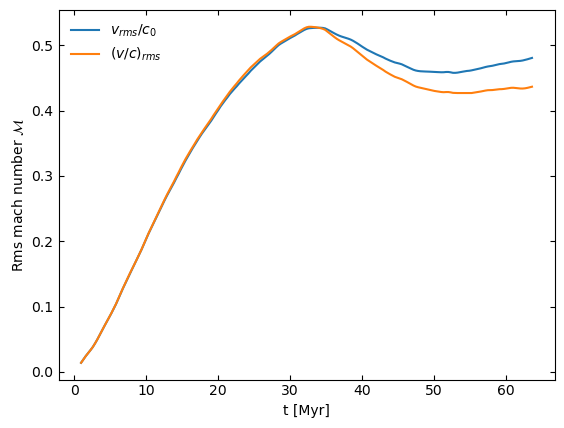

In [6]:
time_bet_snaps = 0.00033025099*978.5 # in Myr

time = np.linspace(0, 197, 198) * time_bet_snaps

plt.plot(time[3:], vals[3:, 1]/vals[0, 0], label=r"$v_{rms}/c_0$")
plt.plot(time[3:], vals[3:, 2], label=r"$(v/c)_{rms}$")
plt.ylabel(r"Rms mach number $\mathcal{M}$")
# plt.yscale("log")
plt.xlabel(r"t [Myr]")
plt.legend(frameon=False)
plt.tick_params(direction='in', top=True, right=True)
plt.savefig(f"{sim}/machnumber.png")

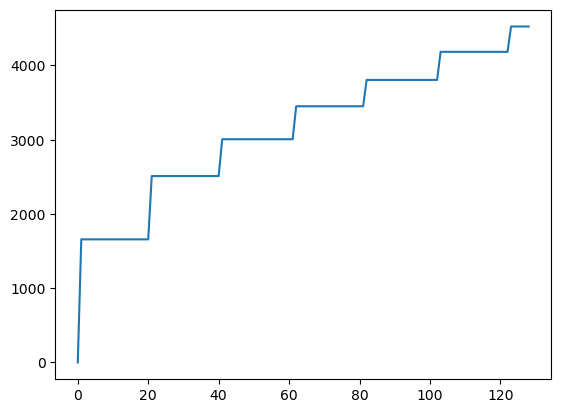

In [7]:
plt.plot(vals[:, 3])

In [20]:
rms_acc = list()

for i in range(0, 220, 10):
    filename = f"{sim}/output/snap_{i:03d}.hdf5" # str(sys.argv[1])
    with h5py.File(filename, 'r') as file:
        gas = file["PartType0"]
        # coordinates = np.array(gas["Coordinates"])
        # velocities = np.array(gas["Velocities"])   
        # density = np.array(gas["Density"])
        # pressure = np.array(gas["Pressure"])
        acc = np.array(gas["Acceleration"])
        # mass = np.array(gas["Masses"])
        rms_acc.append(np.sqrt(np.mean(np.sum(acc**2, axis=1))))

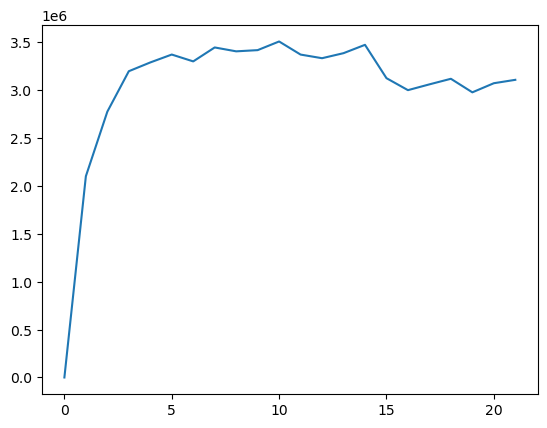

In [21]:
plt.plot(rms_acc)
plt.show()

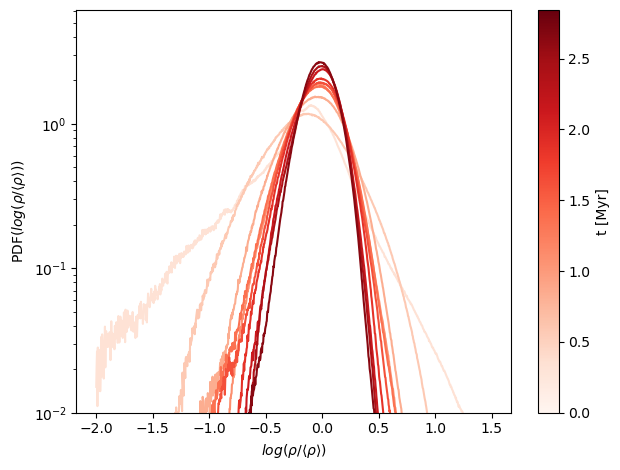

In [9]:
sims = ["driving128-nonsol", "driving64", "driving32", "driving128-mach10", "driving128-mach10-forceramp"]
sim = sims[4]

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

time_bet_snaps = 0.00001321*978.5 # in Myr

times = np.linspace(0, 220, 221) * time_bet_snaps

cmap = plt.get_cmap('Reds')
norm = Normalize(vmin=times.min(), vmax=times.max())

fig, ax = plt.subplots()

for i in range(20, 210, 20):
    mean_hist = np.zeros(1000)
    for j in range(10):
        filename = f"{sim}/output/snap_{i+j:03d}.hdf5" # str(sys.argv[1])
        with h5py.File(filename, 'r') as file:
            gas = file["PartType0"]
            coordinates = np.array(gas["Coordinates"])
            velocities = np.array(gas["Velocities"])   
            density = np.array(gas["Density"])
            pressure = np.array(gas["Pressure"])
            acc = np.array(gas["Acceleration"])
            mass = np.array(gas["Masses"])
        
        volume = mass/density

        rho_zero = np.sum(density * volume)
        hist, bin_edges = np.histogram(np.log10(density/rho_zero), bins=1000, range=(-2.0, 1.5), density=True, weights=volume)
        bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        # plt.plot(bin_centers, hist)
        mean_hist = mean_hist + hist

        color = cmap(norm(times[i + 5]))
    ax.plot(bin_centers, mean_hist/10, color=color)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Only needed for colorbar
cbar = plt.colorbar(sm, ax=ax, label='t [Myr]')
ax.set_yscale("log")
ax.set_ylim(1e-2)
ax.set_xlabel(r'$log(\rho/\langle \rho \rangle)$')
ax.set_ylabel(r'PDF($log(\rho/\langle \rho \rangle)$)')
fig.tight_layout()
fig.savefig(f"{sim}/dens_pdf_evolution.png")

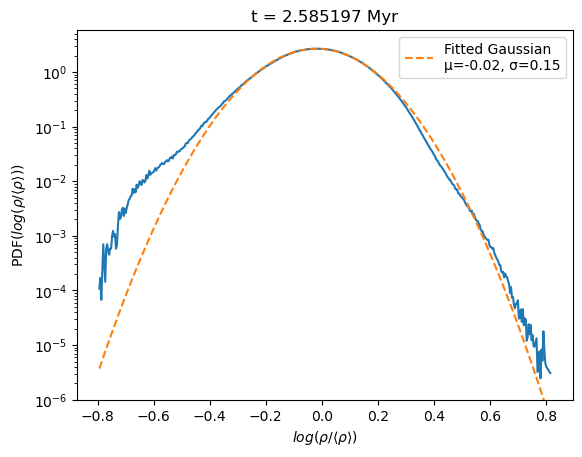

In [33]:
hist = mean_hist/10

idx = hist > 1e-6
hist = hist[idx]

bins = bin_centers[idx]

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Your data: x (points), pdf_vals (values of the PDF at those points)
# x = np.linspace(-5, 5, 100)
# pdf_vals = ...  # your PDF values

# Define a Gaussian function
def gaussian(x, mu, sigma):
    return 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-0.5 * ((x - mu)/sigma)**2)

# Fit the Gaussian
popt, pcov = curve_fit(gaussian, bins, hist)

mu_fit, sigma_fit = popt

# Plot
plt.plot(bins, hist)
plt.plot(bins, gaussian(bins, *popt), label=f'Fitted Gaussian\nμ={mu_fit:.2f}, σ={sigma_fit:.2f}', linestyle='--')
plt.yscale("log")
plt.ylim(1e-6)
plt.legend()
plt.title(f"t = {0.00001321*978.5 * 200} Myr")
plt.xlabel(r'$log(\rho/\langle \rho \rangle)$')
plt.ylabel(r'PDF($log(\rho/\langle \rho \rangle)$)')
plt.savefig(f"{sim}/density_pdf_gaussian_fit.png")


In [ ]:
mean = np.sum(hist * bin_centers * np.diff(bin_edges))

variance = np.sum(hist * bin_centers**2 * np.diff(bin_edges)) - mean**2

b = 0.333333
mach = 1/b * np.sqrt(np.exp(variance) - 1)

gamma = 5/3
soundspeed = np.sqrt(gamma*pressure/density)

mach_real = np.sqrt(np.sum(np.sum(velocities**2, axis=1) * volume)) / np.sum(soundspeed * volume)
print(np.sqrt(np.sum(np.sum(velocities**2, axis=1) * volume)), np.sum(soundspeed * volume))
print(variance, mach, mach_real)

In [ ]:
pressures = list()
for i in range(0, 81):
    filename = f"{sim}/output/snap_{i:03d}.hdf5" # str(sys.argv[1])
    with h5py.File(filename, 'r') as file:
        gas = file["PartType0"]
        coordinates = np.array(gas["Coordinates"])
        velocities = np.array(gas["Velocities"])   
        density = np.array(gas["Density"])
        pressure = np.array(gas["Pressure"])
        acc = np.array(gas["Acceleration"])
        mass = np.array(gas["Masses"])

    
    volume = mass/density
    pressures.append(np.sum(pressure * volume))



In [ ]:
plt.plot(pressures)
plt.show()

In [24]:
# velocity power spectrum measurment

sims = ["driving128-nonsol", "driving64", "driving32", "driving128-mach10"]
sim = sims[3]

i = 60
filename = f"{sim}/output/snap_{i:03d}.hdf5" # str(sys.argv[1])
with h5py.File(filename, 'r') as file:
    gas = file["PartType0"]
    coordinates = np.array(gas["Coordinates"])
    velocities = np.array(gas["Velocities"])   
    density = np.array(gas["Density"])
    pressure = np.array(gas["Pressure"])
    acc = np.array(gas["Acceleration"])
    mass = np.array(gas["Masses"])


grid = 100
structured_velocity = map_unstructured_to_structured_3d_optimized(coordinates, velocities, (grid, grid, grid))

vel_fourier = np.fft.fftn(structured_velocity, norm="ortho")

In [ ]:
vel_fourier_mag = np.sqrt(np.sum(np.abs(np.fft.fftshift(vel_fourier))**2, axis=3)).ravel()

box_size = 1
k_vals = 2*np.pi/box_size * np.linspace(-grid/2, grid/2 - 1, grid)

KX, KY, KZ = np.meshgrid(k_vals, k_vals, k_vals, indexing='ij')  # shape: (Nx, Ny, Nz)

# Now the full 3D wavevector field:
k_modes = np.stack((KX, KY, KZ), axis=-1)  # shape: (Nx, Ny, Nz, 3)

k_mag = np.sqrt(np.sum(k_modes**2, axis=3)).ravel()

k_min = k_mag[k_mag > 0].min()
k_max = k_mag.max()
num_bins = 1000

bins = np.linspace(k_min, k_max, num_bins + 1)

radial_avg, bin_edges, _ = binned_statistic(
    k_mag, vel_fourier_mag, statistic='mean', bins=bins
)

bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

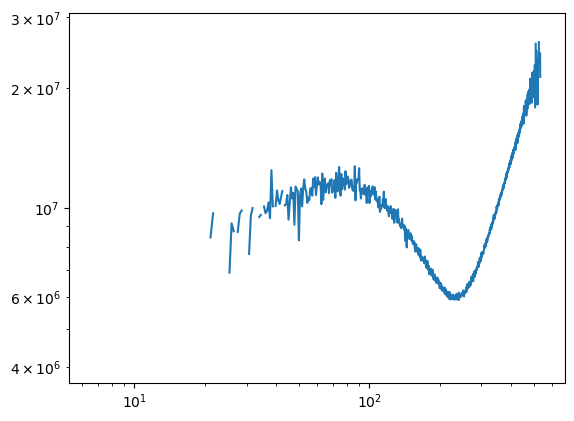

In [26]:
plt.plot(bin_centers, radial_avg*bin_centers**2)
plt.xscale("log")
plt.yscale("log")

In [ ]:
print(bin_centers[0], radial_avg[0])
print(bin_centers.shape, radial_avg.shape)

In [ ]:
np.where(k_mag < 12)

In [10]:
def measure_1d_power_spectrum_vector_field(v, boxsize=1.0, bins=200):
    """
    Computes the 1D power spectrum of a 3D vector field defined on a uniform grid.

    Parameters
    ----------
    v : ndarray, shape (Nx, Ny, Nz, 3)
        Real-space 3D vector field.
    boxsize : float or tuple
        Physical size of the domain (assumes cubic if float).
    bins : int or array
        Number of radial bins or custom bin edges (in k-space).

    Returns
    -------
    k_bin_centers : ndarray
        Centers of the k bins (in units of 1/boxsize).
    Pk : ndarray
        Power spectrum P(k) averaged in each shell.
    """
    assert v.ndim == 4 and v.shape[-1] == 3, "Field must be 3D vector on grid"

    Nx, Ny, Nz, _ = v.shape
    Lx, Ly, Lz = (boxsize, boxsize, boxsize) if np.isscalar(boxsize) else boxsize

    # Compute FFT of each component
    v_k = np.fft.fftn(v, norm="ortho")
    # v_k = np.fft.fftshift(v_k)  # center zero mode (optional)
    power = np.sum(np.abs(v_k)**2, axis=-1)  # sum over components, shape: (Nx,Ny,Nz)

    # Build k-space grid
    kx = np.fft.fftfreq(Nx, d=Lx / Nx) * 2 * np.pi
    ky = np.fft.fftfreq(Ny, d=Ly / Ny) * 2 * np.pi
    kz = np.fft.fftfreq(Nz, d=Lz / Nz) * 2 * np.pi
    kx, ky, kz = np.meshgrid(kx, ky, kz, indexing='ij')
    k = np.sqrt(kx**2 + ky**2 + kz**2).ravel()
    power = power.ravel()

    # Define bins in log space
    k_nonzero = k[k > 0]
    k_min = k_nonzero.min()
    k_max = k.max()

    if np.isscalar(bins):
        bin_edges = np.logspace(np.log10(k_min), np.log10(k_max), bins + 1)
    else:
        bin_edges = np.asarray(bins)

    # Bin the power spectrum
    Pk, _, _ = binned_statistic(k, power, bins=bin_edges, statistic='mean')
    k_bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

    Pk *= k_bin_centers**2

    return k_bin_centers, Pk


# velocity power spectrum measurment

sims = ["driving128-nonsol", "driving64", "driving32", "driving128-mach10"]
sim = sims[3]

grid = 100
Pk_avg = np.zeros(grid)
num = 20
for i in range(40, 40+num):
    print(i)
    filename = f"{sim}/output/snap_{i:03d}.hdf5" # str(sys.argv[1])
    with h5py.File(filename, 'r') as file:
        gas = file["PartType0"]
        coordinates = np.array(gas["Coordinates"])
        velocities = np.array(gas["Velocities"])   
        density = np.array(gas["Density"])
        pressure = np.array(gas["Pressure"])
        acc = np.array(gas["Acceleration"])
        mass = np.array(gas["Masses"])


    structured_velocity = map_unstructured_to_structured_3d_optimized(coordinates, velocities, (grid, grid, grid))

    k_bins, Pk = measure_1d_power_spectrum_vector_field(structured_velocity)
    valid = ~np.isnan(Pk)
    Pk_avg[valid] = Pk_avg[valid] + Pk[valid]


Pk_avg = Pk_avg/num

40


KeyboardInterrupt: 

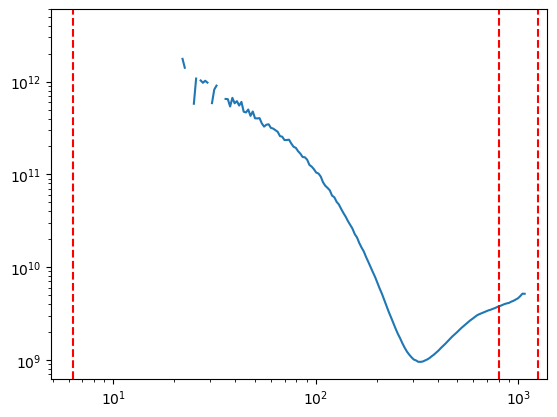

In [8]:
plt.plot(k_bins, Pk)
plt.xscale("log")
plt.yscale("log")
plt.axvline(x=2*np.pi/1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=2*np.pi/1 * 128, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=2*np.pi/1 * grid, color='r', linestyle='--', linewidth=1.5)
plt.show()

In [9]:
Pk.shape

(200,)